In [1]:
  from sklearn.datasets import load_iris

In [2]:
iris = load_iris(as_frame = True)

In [3]:
print(iris)

{'data':      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns], 'target': 0      0
1      0
2 

In [4]:
X = iris.data

In [5]:
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [6]:
y = iris.target

In [7]:
y

,target
0,0
1,0
2,0
3,0
4,0
...,...
145,2
146,2
147,2
148,2


In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=41)

In [10]:
X_train

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
79,5.7,2.6,3.5,1.0
54,6.5,2.8,4.6,1.5
106,4.9,2.5,4.5,1.7
90,5.5,2.6,4.4,1.2
145,6.7,3.0,5.2,2.3
...,...,...,...,...
26,5.0,3.4,1.6,0.4
89,5.5,2.5,4.0,1.3
65,6.7,3.1,4.4,1.4
80,5.5,2.4,3.8,1.1


In [11]:
X_test

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
119,6.0,2.2,5.0,1.5
128,6.4,2.8,5.6,2.1
135,7.7,3.0,6.1,2.3
91,6.1,3.0,4.6,1.4
112,6.8,3.0,5.5,2.1
71,6.1,2.8,4.0,1.3
123,6.3,2.7,4.9,1.8
85,6.0,3.4,4.5,1.6
147,6.5,3.0,5.2,2.0
143,6.8,3.2,5.9,2.3


In [12]:
y_test

,target
119,2
128,2
135,2
91,1
112,2
71,1
123,2
85,1
147,2
143,2


In [13]:
from sklearn.neighbors import KNeighborsClassifier

In [14]:
model = KNeighborsClassifier(n_neighbors=3)

In [15]:
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [16]:
y_pred = model.predict(X_test)

In [17]:
y_pred

array([1, 2, 2, 1, 2, 1, 2, 1, 2, 2, 2, 0, 0, 1, 0, 2, 0, 2, 0, 0, 1, 2,
       0, 0, 1, 1, 1, 1, 0, 1])

In [18]:
y_test.to_numpy()

array([2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 2, 0, 0, 1, 0, 2, 0, 1, 0, 0, 1, 2,
       0, 0, 1, 1, 1, 1, 0, 1])

In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [20]:
accuracy = accuracy_score(y_test, y_pred)

In [21]:
accuracy

0.9333333333333333

In [22]:
28/30

0.9333333333333333

In [23]:
cm = confusion_matrix(y_test, y_pred)

In [24]:
print(cm)

[[ 9  0  0]
 [ 0 10  1]
 [ 0  1  9]]


In [25]:
cm

array([[ 9,  0,  0],
       [ 0, 10,  1],
       [ 0,  1,  9]])

# Actividad 1

1. Cambiar el valor de n_neighbors.
2. Probar al menos tres valores diferentes.
3. Registrar el accuracy obtenido en cada caso.
4. Registrar la matriz de confusión obtenida en cada caso.
5. Discutir si el mejor resultado observado necesariamente implica el
mejor modelo.


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.style.use("fivethirtyeight")
plt.rcParams['figure.figsize'] = (16/1.5, 9/1.5)

In [27]:
accs = {} # un dic para guardar {vecinos, acc}

ks = range(1, 30) # numero de vecinos

# lo mismo de antes
for i in ks:
  model = KNeighborsClassifier(n_neighbors=i)
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  print('Número de vecinos: ', i)
  accuracy = accuracy_score(y_test, y_pred)
  print('Exactitud: ', round(accuracy, 2))
  print('Matriz de confusión:')
  print(confusion_matrix(y_test, y_pred))
  print('')
  accs[i] = accuracy

Número de vecinos:  1
Exactitud:  0.9
Matriz de confusión:
[[ 9  0  0]
 [ 0 10  1]
 [ 0  2  8]]

Número de vecinos:  2
Exactitud:  0.9
Matriz de confusión:
[[ 9  0  0]
 [ 0 10  1]
 [ 0  2  8]]

Número de vecinos:  3
Exactitud:  0.93
Matriz de confusión:
[[ 9  0  0]
 [ 0 10  1]
 [ 0  1  9]]

Número de vecinos:  4
Exactitud:  0.9
Matriz de confusión:
[[ 9  0  0]
 [ 0 10  1]
 [ 0  2  8]]

Número de vecinos:  5
Exactitud:  0.97
Matriz de confusión:
[[ 9  0  0]
 [ 0 10  1]
 [ 0  0 10]]

Número de vecinos:  6
Exactitud:  0.93
Matriz de confusión:
[[ 9  0  0]
 [ 0 10  1]
 [ 0  1  9]]

Número de vecinos:  7
Exactitud:  0.97
Matriz de confusión:
[[ 9  0  0]
 [ 0 10  1]
 [ 0  0 10]]

Número de vecinos:  8
Exactitud:  0.93
Matriz de confusión:
[[ 9  0  0]
 [ 0 10  1]
 [ 0  1  9]]

Número de vecinos:  9
Exactitud:  0.97
Matriz de confusión:
[[ 9  0  0]
 [ 0 10  1]
 [ 0  0 10]]

Número de vecinos:  10
Exactitud:  0.97
Matriz de confusión:
[[ 9  0  0]
 [ 0 10  1]
 [ 0  0 10]]

Número de vecinos:  11

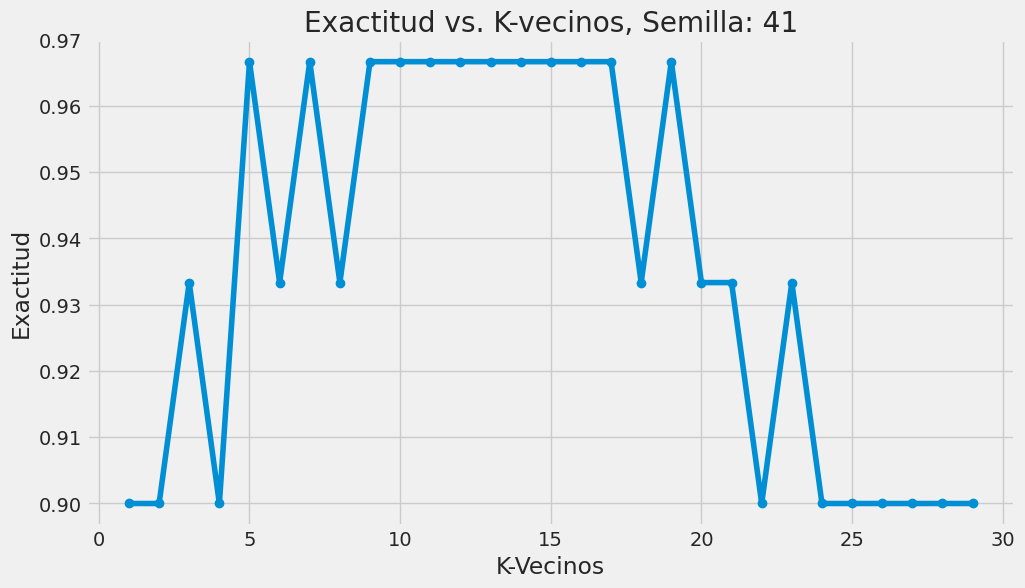

In [28]:
# plot the accs
plt.figure()
plt.plot(ks, list(accs.values()), marker='o')
plt.title('Exactitud vs. K-vecinos, Semilla: 41')
plt.xlabel('K-Vecinos')
plt.ylabel('Exactitud')
plt.show()

# Actividad 2

1. Cambiar el valor de random_state en
train_test_split(X,y,test_size=0.2,random_state=41)
2. Probar el valor de 42, y otros dos valores (enteros) diferentes.
3. Registrar el accuracy obtenido en cada caso.
4. Registrar la matriz de confusión obtenida en cada caso.
5. Discutir acerca de los resultados obtenidos.

In [29]:
num_seeds = 100
seeds = range(41, 41 + num_seeds)

accs = {}

for s in seeds:
  print('------------------')
  print('Semilla: ', s)
  X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=s)

  # lo mismo mismo de antes
  for i in ks:
    model = KNeighborsClassifier(n_neighbors=i)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accs[(s, i)] = accuracy # los guarda como {(seed, k): acc}

    if s<44:
      print('Número de vecinos: ', i)
      print('Exactitud: ', round(accuracy, 2))
      print('Matriz de confusión:')
      print(confusion_matrix(y_test, y_pred))
      print('')

------------------
Semilla:  41
Número de vecinos:  1
Exactitud:  0.9
Matriz de confusión:
[[ 9  0  0]
 [ 0 10  1]
 [ 0  2  8]]

Número de vecinos:  2
Exactitud:  0.9
Matriz de confusión:
[[ 9  0  0]
 [ 0 10  1]
 [ 0  2  8]]

Número de vecinos:  3
Exactitud:  0.93
Matriz de confusión:
[[ 9  0  0]
 [ 0 10  1]
 [ 0  1  9]]

Número de vecinos:  4
Exactitud:  0.9
Matriz de confusión:
[[ 9  0  0]
 [ 0 10  1]
 [ 0  2  8]]

Número de vecinos:  5
Exactitud:  0.97
Matriz de confusión:
[[ 9  0  0]
 [ 0 10  1]
 [ 0  0 10]]

Número de vecinos:  6
Exactitud:  0.93
Matriz de confusión:
[[ 9  0  0]
 [ 0 10  1]
 [ 0  1  9]]

Número de vecinos:  7
Exactitud:  0.97
Matriz de confusión:
[[ 9  0  0]
 [ 0 10  1]
 [ 0  0 10]]

Número de vecinos:  8
Exactitud:  0.93
Matriz de confusión:
[[ 9  0  0]
 [ 0 10  1]
 [ 0  1  9]]

Número de vecinos:  9
Exactitud:  0.97
Matriz de confusión:
[[ 9  0  0]
 [ 0 10  1]
 [ 0  0 10]]

Número de vecinos:  10
Exactitud:  0.97
Matriz de confusión:
[[ 9  0  0]
 [ 0 10  1]
 [ 0

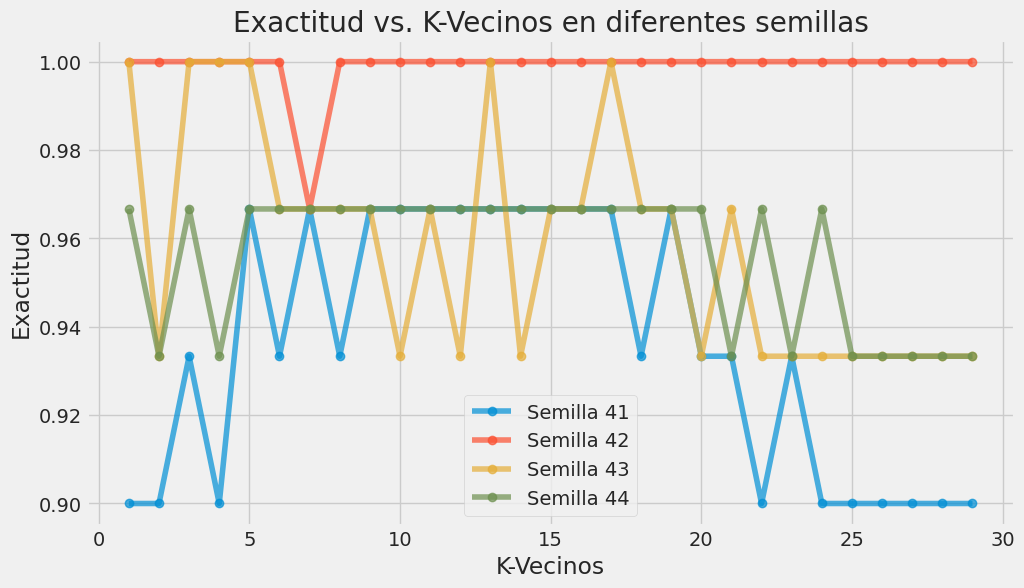

In [30]:
plt.figure()

# para las primeras n semillas:
lineas = 4
for s in seeds[:lineas]:
    accs_seed = [accs[(s, i)] for i in ks] # obtenemos el acc en los k-vecinos
    # graficamos la linea de
    plt.plot(ks, accs_seed, marker='o', label=f'Semilla {s}', alpha=0.7)

plt.title('Exactitud vs. K-Vecinos en diferentes semillas')
plt.xlabel('K-Vecinos')
plt.ylabel('Exactitud')
plt.legend()
plt.show()

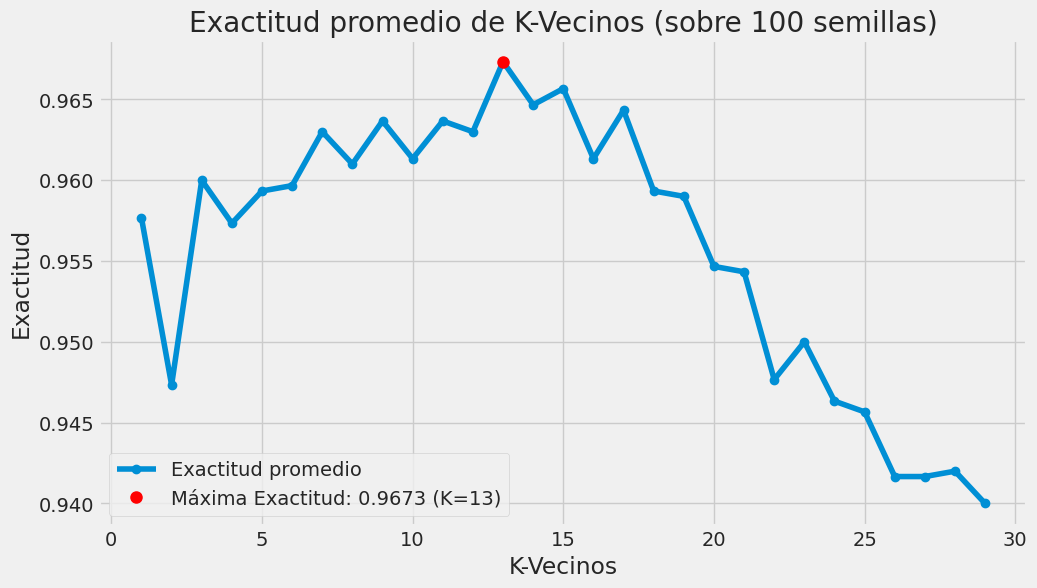

In [31]:
plt.figure()

avg_accs_k = []

# para todos los vecinos
for k in ks:
    accs_k = [accs[(s, k)] for s in seeds] # todas las accs
    avg_acc = sum(accs_k) / len(accs_k)
    avg_accs_k.append(avg_acc)

plt.plot(ks, avg_accs_k, marker='o', label='Exactitud promedio')

# resaltar el mas grande
maximo = max(avg_accs_k)
# Encontrar el índice del valor máximo
indice_max = avg_accs_k.index(maximo)
# Obtener el valor de K correspondiente
k_max = ks[indice_max]
# Plot
plt.plot(k_max, maximo, 'ro', markersize=8, label=f'Máxima Exactitud: {maximo:.4f} (K={k_max})')


plt.title(f'Exactitud promedio de K-Vecinos (sobre {num_seeds} semillas)')
plt.xlabel('K-Vecinos')
plt.ylabel('Exactitud')
plt.legend()
plt.show()